In [41]:
import pandas as pd
import numpy as np

df=pd.read_csv("/content/MRF.NS.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2002-07-01,910.0,910.0,880.0,897.599976,815.841370,426.0
1,2002-07-02,900.0,905.0,895.0,903.650024,821.340393,310.0
2,2002-07-03,910.0,910.0,900.0,906.700012,824.112366,336.0
3,2002-07-04,920.0,925.0,910.0,916.799988,833.292358,591.0
4,2002-07-05,915.0,935.0,910.0,927.299988,842.836182,1623.0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4793 entries, 0 to 4792
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4793 non-null   object 
 1   Open       4776 non-null   float64
 2   High       4776 non-null   float64
 3   Low        4776 non-null   float64
 4   Close      4776 non-null   float64
 5   Adj Close  4776 non-null   float64
 6   Volume     4776 non-null   float64
dtypes: float64(6), object(1)
memory usage: 262.2+ KB


In [43]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,4776.000000,4776.000000,4776.000000,4776.000000,4776.000000,4776.000000
mean,24999.539156,25311.247821,24668.073474,24962.025982,24786.351552,9182.982831
std,27134.259259,27428.987474,26802.876610,27091.317441,27055.070703,12670.355564
min,779.450012,828.000000,779.450012,814.849976,743.103821,0.000000
25%,3260.000000,3316.437500,3199.750000,3242.549988,3112.166565,2266.250000
50%,9296.500000,9425.000000,9171.500000,9257.950195,9064.432617,5844.500000
75%,50399.237305,50946.750000,49711.187500,50195.249024,49910.255859,11105.250000
max,96770.000000,98599.953125,92750.000000,96973.851563,96910.757813,281075.000000


In [44]:
data_length=df.shape[0]
print(data_length)

4793


In [45]:
df.isnull().sum()

,0
Date,0
Open,17
High,17
Low,17
Close,17
Adj Close,17
Volume,17


In [46]:
data=df.copy()

In [47]:
#drop the date column in data
#data.drop("Date", inplace=True, axis=1)



In [48]:
#fill the missing null values with mean

col=["Open","High","Low","Close","Adj Close","Volume"]
for i in col:
  data[i].fillna(data[i].mean(),inplace=True)

<ipython-input-48-7227b91153e8>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].fillna(data[i].mean(),inplace=True)


In [49]:
data.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [50]:
#filtering the rows from 1/5/2023 to 1/5/2024



In [51]:
# prompt: #filtering the rows from 1/2/2020 to 1/5/2021

# Convert the 'Date' column to datetime objects
data['Date'] = pd.to_datetime(data['Date'])

# Filter the data
start_date = '2020-02-01'
end_date = '2021-05-01'
filtered_data = data[(data['Date'] >= start_date) & (data['Date'] <= end_date)]

# Display or use the filtered data
filtered_data

,Date,Open,High,Low,Close,Adj Close,Volume
4381,2020-02-03,68690.000000,69888.000000,68000.000000,69462.648438,69301.562500,6669.0
4382,2020-02-04,69650.000000,71899.000000,69650.000000,71680.148438,71513.914063,12327.0
4383,2020-02-05,71680.148438,73565.703125,71680.148438,72390.796875,72222.921875,10788.0
4384,2020-02-06,72599.000000,73100.000000,71260.000000,71636.351563,71470.226563,5926.0
4385,2020-02-07,71899.000000,71900.000000,70371.250000,70960.453125,70795.890625,5974.0
...,...,...,...,...,...,...,...
4684,2021-04-26,78550.000000,79296.398438,77484.500000,77687.546875,77639.601563,16483.0
4685,2021-04-27,77900.000000,78472.898438,77700.000000,78010.398438,77962.257813,13283.0
4686,2021-04-28,78390.000000,79300.000000,77850.000000,78060.796875,78012.625000,23446.0
4687,2021-04-29,78600.000000,79100.000000,77505.000000,77656.898438,77608.976563,18240.0


In [52]:
filtered_data.shape

(308, 7)

In [53]:
data=filtered_data.copy()

In [54]:
data_length=data.shape[0]
print(data_length)

308


In [55]:
#feature construction

data["open_close"]=(data["Open"]-data["Close"])/data.Open
data["high_low"]=(data["High"]-data["Low"])/data.Low
data["percentage_change"]=data["Adj Close"].pct_change()  #Percentage Change  =  (Current Value − Previous Value/100)/Previous Value
data["std_5"]=data["percentage_change"].rolling(5).std()
data["ret_5"]=data["percentage_change"].rolling(5).mean()


In [56]:
"""
Pct_Change  =  (Current Value − Previous Value/100)/Previous Value

shift(-1)  =  Shift values by 1 period upwards

"""

'\nPct_Change  =  (Current\xa0Value − Previous\xa0Value/100)/Previous\xa0Value\n\nshift(-1)  =  Shift values by 1 period upwards\n\n'

In [57]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume,open_close,high_low,percentage_change,std_5,ret_5
4381,2020-02-03,68690.000000,69888.000000,68000.000000,69462.648438,69301.562500,6669.0,-0.011248,0.027765,NaN,NaN,NaN
4382,2020-02-04,69650.000000,71899.000000,69650.000000,71680.148438,71513.914063,12327.0,-0.029148,0.032290,0.031924,NaN,NaN
4383,2020-02-05,71680.148438,73565.703125,71680.148438,72390.796875,72222.921875,10788.0,-0.009914,0.026305,0.009914,NaN,NaN
4384,2020-02-06,72599.000000,73100.000000,71260.000000,71636.351563,71470.226563,5926.0,0.013260,0.025821,-0.010422,NaN,NaN
4385,2020-02-07,71899.000000,71900.000000,70371.250000,70960.453125,70795.890625,5974.0,0.013054,0.021724,-0.009435,NaN,NaN


In [58]:
data.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
open_close,0
high_low,0
percentage_change,1


In [59]:
data.dropna(inplace=True)

In [60]:
data.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
open_close,0
high_low,0
percentage_change,0


In [61]:
data.shape

(303, 12)

In [62]:
#data splitting

X=data[["open_close","high_low","std_5","ret_5"]]

Y=np.where(data["Adj Close"].shift(-1)> data["Adj Close"],1,-1)


In [63]:
#total data set length

dataset_length=data.shape[0]

#training data set length
split=int(dataset_length*0.75)
split

227

In [64]:
#splitting the X and Y into train and test datasets
X_train, X_test=X[:split],X[split:]
Y_train, Y_test=Y[:split],Y[split:]

#print the size of the train and test data set

print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(227, 4) (76, 4)
(227,) (76,)


In [65]:
from sklearn.ensemble import RandomForestClassifier

clf=RandomForestClassifier(random_state=5)



In [66]:
model=clf.fit(X_train,Y_train)

In [67]:
y_pred=model.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

accuracy=accuracy_score(Y_test,y_pred)
print("accuracy : ",accuracy)


accuracy :  0.5263157894736842


In [69]:
#confusion matrix

cm=confusion_matrix(Y_test,y_pred)
print("confusion matrix : ",cm)

confusion matrix :  [[25 17]
 [19 15]]


In [70]:
classification_report=classification_report(Y_test,y_pred)
print("classification report : ",classification_report)

classification report :                precision    recall  f1-score   support

          -1       0.57      0.60      0.58        42
           1       0.47      0.44      0.45        34

    accuracy                           0.53        76
   macro avg       0.52      0.52      0.52        76
weighted avg       0.52      0.53      0.52        76



In [71]:
"""
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy
accuracy = accuracy_score(Y_test, y_pred)
print("accuracy : ", accuracy)

# Calculate confusion matrix
# Ensure 'confusion_matrix' refers to the function, not a previous result
cm = confusion_matrix(Y_test, y_pred)
print("confusion matrix : ", cm)

# Print classification report
classification_report_result = classification_report(Y_test, y_pred)
print("classification report : ", classification_report_result)"""

'\nfrom sklearn.metrics import accuracy_score, confusion_matrix, classification_report\n\n# Calculate accuracy\naccuracy = accuracy_score(Y_test, y_pred)\nprint("accuracy : ", accuracy)\n\n# Calculate confusion matrix\n# Ensure \'confusion_matrix\' refers to the function, not a previous result\ncm = confusion_matrix(Y_test, y_pred)\nprint("confusion matrix : ", cm)\n\n# Print classification report\nclassification_report_result = classification_report(Y_test, y_pred)\nprint("classification report : ", classification_report_result)'

In [72]:
data["strategy_returns"]=data.percentage_change	.shift(-1)*model.predict(X)

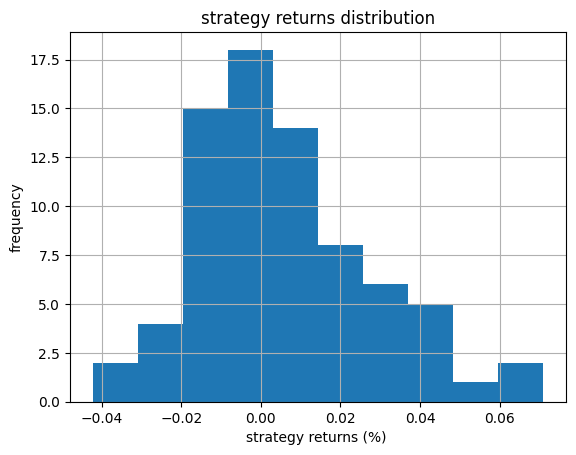

In [73]:
#matplotlib inline

import matplotlib.pyplot as plt
data.strategy_returns[split:].hist()
plt.xlabel("strategy returns (%) ")
plt.ylabel("frequency")
plt.title("strategy returns distribution")
plt.show()

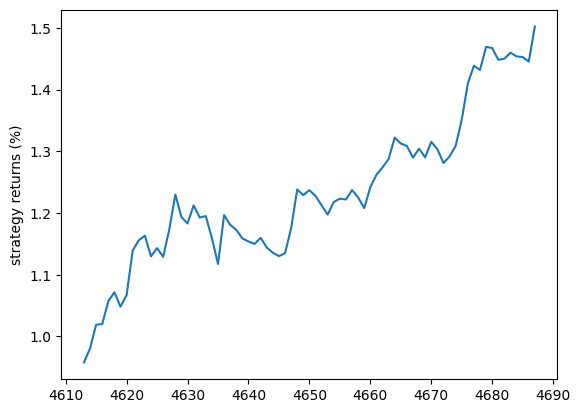

In [74]:
(data.strategy_returns[split:]+1).cumprod().plot()
plt.ylabel("strategy returns (%)")
plt.show()

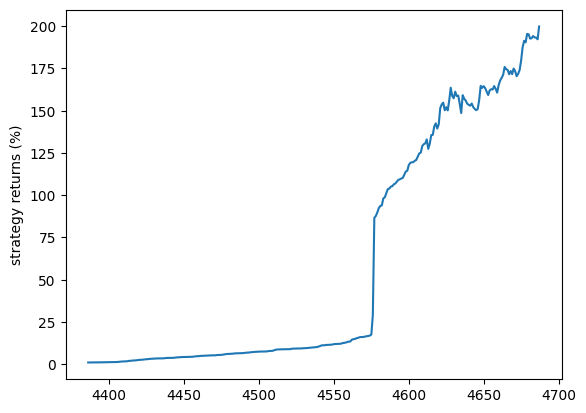

In [75]:
(data.strategy_returns+1).cumprod().plot()
plt.ylabel("strategy returns (%)")
plt.show()